# 풍력 발전량 데이터 nogada

이 노트북은 `TRAIN/` 폴더의 SCADA(터빈 실측) 데이터에 집중함

1. 터빈 데이터를 KPX 그룹(1, 2, 3) 단위로 합치기
2. 월별 발전량 추이 확인
3. 풍속·풍향과 발전량을 비교
4. "풍속이 셀수록 발전량이 느는가?" 같은 질문을 숫자(상관계수)로 확인

## 0. 라이브러리와 경로 설정

In [63]:
# 이 노트북에서 사용할 라이브러리
import pandas as pd  # 표(csv) 데이터를 다루는 라이브러리
import numpy as np  # 숫자 계산(특히 배열/각도 연산)을 도와주는 라이브러리
import matplotlib.pyplot as plt  # 그래프를 그리는 라이브러리
from pathlib import Path  # 폴더/파일 경로를 다루기 쉽게 해주는 도구

# 데이터가 들어있는 폴더 경로를 변수로 저장
TRAIN_DIR = Path("TRAIN")  # 학습용 csv 파일들이 들어있는 폴더
INFO_DIR = Path("INFO")  # 터빈-그룹 매핑 정보(info.xlsx)가 들어있는 폴더

# 그래프에 한글이 깨지지 않도록 폰트를 지정
plt.rcParams["font.family"] = "Malgun Gothic"  # 국룰
plt.rcParams["axes.unicode_minus"] = False  # 마이너스(-) 기호가 깨지는 것을 방지

## 1. 원본 SCADA 데이터 읽어보기

`scada_vestas_train.csv`는 VESTAS 터빈 12기, `scada_unison_train.csv`는 UNISON 터빈 5기의
**10분 간격** 실측 데이터입니다. 컬럼은 터빈별 발전량(`_power_kw10m`), 풍속(`_ws`), 풍향(`_wd`)으로 구성됩니다.

In [59]:
# VESTAS 터빈 SCADA 데이터 로드 (10분 간격 실측치)
vestas = pd.read_csv(TRAIN_DIR / "scada_vestas_train.csv")  # csv 파일을 표(DataFrame)로 읽기
vestas["kst_dtm"] = pd.to_datetime(vestas["kst_dtm"])  # 시간 컬럼을 문자열에서 진짜 '날짜/시간' 타입으로 변환

# UNISON 터빈 SCADA 데이터 로드 (10분 간격 실측치)
unison = pd.read_csv(TRAIN_DIR / "scada_unison_train.csv")  # csv 파일을 표(DataFrame)로 읽기
unison["kst_dtm"] = pd.to_datetime(unison["kst_dtm"])  # 시간 컬럼을 날짜/시간 타입으로 변환

print("VESTAS 데이터 크기:", vestas.shape)  # (행 개수, 열 개수) 출력
print("UNISON 데이터 크기:", unison.shape)  # (행 개수, 열 개수) 출력
vestas.head()  # vestas 데이터 보기
unison.head()  # UNISON 데이터 보기

VESTAS 데이터 크기: (157819, 37)
UNISON 데이터 크기: (105264, 16)


,kst_dtm,unison_wtg01_power_kw10m,unison_wtg02_power_kw10m,unison_wtg03_power_kw10m,unison_wtg04_power_kw10m,unison_wtg05_power_kw10m,unison_wtg01_ws,unison_wtg02_ws,unison_wtg03_ws,unison_wtg04_ws,unison_wtg05_ws,unison_wtg01_wd,unison_wtg02_wd,unison_wtg03_wd,unison_wtg04_wd,unison_wtg05_wd
0,2023-01-01 00:10:00,706.0,702.0,0.0,705.0,707.0,13.73,15.03,16.42,13.97,14.57,-79.005327,-69.946609,-124.739623,-90.938062,-130.941880
1,2023-01-01 00:20:00,706.0,702.0,0.0,684.0,708.0,13.61,14.76,16.51,14.96,14.34,-77.479172,-68.192593,-122.671765,-87.976756,-131.394959
2,2023-01-01 00:30:00,708.0,702.0,0.0,408.0,706.0,14.59,14.70,16.41,12.68,13.55,-75.624282,-67.050591,-122.046216,-87.009944,-132.164142
3,2023-01-01 00:40:00,699.0,384.0,0.0,702.0,706.0,14.62,15.64,15.28,12.46,14.37,-76.608166,-66.836232,-122.675858,-88.533341,-132.392295
4,2023-01-01 00:50:00,610.0,471.0,0.0,698.0,706.0,14.20,15.36,14.79,14.16,14.95,-76.231935,-65.485185,-123.190201,-88.352211,-132.589051


In [39]:
vestas.info()

<class 'pandas.DataFrame'>
RangeIndex: 157819 entries, 0 to 157818
Data columns (total 37 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   kst_dtm                   157819 non-null  datetime64[us]
 1   vestas_wtg01_power_kw10m  157819 non-null  int64         
 2   vestas_wtg02_power_kw10m  157819 non-null  int64         
 3   vestas_wtg03_power_kw10m  157819 non-null  int64         
 4   vestas_wtg04_power_kw10m  157819 non-null  int64         
 5   vestas_wtg05_power_kw10m  157819 non-null  int64         
 6   vestas_wtg06_power_kw10m  157819 non-null  int64         
 7   vestas_wtg07_power_kw10m  157819 non-null  int64         
 8   vestas_wtg08_power_kw10m  157819 non-null  int64         
 9   vestas_wtg09_power_kw10m  157819 non-null  int64         
 10  vestas_wtg10_power_kw10m  157819 non-null  int64         
 11  vestas_wtg11_power_kw10m  157819 non-null  int64         
 12  vestas_wtg12_

In [40]:
unison.info()

<class 'pandas.DataFrame'>
RangeIndex: 105264 entries, 0 to 105263
Data columns (total 16 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   kst_dtm                   105264 non-null  datetime64[us]
 1   unison_wtg01_power_kw10m  105056 non-null  float64       
 2   unison_wtg02_power_kw10m  103902 non-null  float64       
 3   unison_wtg03_power_kw10m  104912 non-null  float64       
 4   unison_wtg04_power_kw10m  105114 non-null  float64       
 5   unison_wtg05_power_kw10m  105122 non-null  float64       
 6   unison_wtg01_ws           103798 non-null  float64       
 7   unison_wtg02_ws           103840 non-null  float64       
 8   unison_wtg03_ws           104817 non-null  float64       
 9   unison_wtg04_ws           104884 non-null  float64       
 10  unison_wtg05_ws           103885 non-null  float64       
 11  unison_wtg01_wd           105056 non-null  float64       
 12  unison_wtg02_

In [60]:
vestas.columns

Index(['kst_dtm', 'vestas_wtg01_power_kw10m', 'vestas_wtg02_power_kw10m',
       'vestas_wtg03_power_kw10m', 'vestas_wtg04_power_kw10m',
       'vestas_wtg05_power_kw10m', 'vestas_wtg06_power_kw10m',
       'vestas_wtg07_power_kw10m', 'vestas_wtg08_power_kw10m',
       'vestas_wtg09_power_kw10m', 'vestas_wtg10_power_kw10m',
       'vestas_wtg11_power_kw10m', 'vestas_wtg12_power_kw10m',
       'vestas_wtg01_ws', 'vestas_wtg02_ws', 'vestas_wtg03_ws',
       'vestas_wtg04_ws', 'vestas_wtg05_ws', 'vestas_wtg06_ws',
       'vestas_wtg07_ws', 'vestas_wtg08_ws', 'vestas_wtg09_ws',
       'vestas_wtg10_ws', 'vestas_wtg11_ws', 'vestas_wtg12_ws',
       'vestas_wtg01_wd', 'vestas_wtg02_wd', 'vestas_wtg03_wd',
       'vestas_wtg04_wd', 'vestas_wtg05_wd', 'vestas_wtg06_wd',
       'vestas_wtg07_wd', 'vestas_wtg08_wd', 'vestas_wtg09_wd',
       'vestas_wtg10_wd', 'vestas_wtg11_wd', 'vestas_wtg12_wd'],
      dtype='str')

In [61]:
unison.info()

<class 'pandas.DataFrame'>
RangeIndex: 105264 entries, 0 to 105263
Data columns (total 16 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   kst_dtm                   105264 non-null  datetime64[us]
 1   unison_wtg01_power_kw10m  105056 non-null  float64       
 2   unison_wtg02_power_kw10m  103902 non-null  float64       
 3   unison_wtg03_power_kw10m  104912 non-null  float64       
 4   unison_wtg04_power_kw10m  105114 non-null  float64       
 5   unison_wtg05_power_kw10m  105122 non-null  float64       
 6   unison_wtg01_ws           103798 non-null  float64       
 7   unison_wtg02_ws           103840 non-null  float64       
 8   unison_wtg03_ws           104817 non-null  float64       
 9   unison_wtg04_ws           104884 non-null  float64       
 10  unison_wtg05_ws           103885 non-null  float64       
 11  unison_wtg01_wd           105056 non-null  float64       
 12  unison_wtg02_

## 2. 터빈이 어느 KPX 그룹인지 표 만들기

발전량 라벨(`train_labels.csv`)은 터빈 단위가 아니라 **KPX 그룹(1, 2, 3) 단위**
어떤 터빈이 어느 그룹인지는 `INFO/info.xlsx`에 적혀 있으므로, 이 파일을 읽어 매핑 사전(dict) 만듦

In [ ]:
# 터빈-그룹 정보가 담긴 엑셀 파일 로드 (3번째 줄부터 진짜 표가 시작되어 header=2)
info = pd.read_excel(INFO_DIR / "info.xlsx", header=2)  # 엑셀 파일을 표로 읽기
info = info.iloc[:, 1:]  # 맨 앞의 빈 열 하나를 제거
info.columns = info.iloc[0]  # 첫 번째 줄 내용을 실제 컬럼 이름으로 사용
info = info.iloc[1:].reset_index(drop=True)  # 컬럼 이름으로 쓴 첫 줄은 지우고 인덱스 재설정
info["KPX그룹"] = info["KPX그룹"].ffill().astype(int)  # 병합된 셀이라 비어 있던 그룹 번호를 바로 위 값으로 채우기

# "vestas_wtg01" -> "kpx_group_1" 처럼 딕셔너리 만들기
vestas_group = {}  # VESTAS 터빈용 빈 사전
unison_group = {}  # UNISON 터빈용 빈 사전
turbine_cap_kwh10m = {}  # 터빈별 '10분 동안 낼 수 있는 최대 발전량(kWh)'을 담을 사전 (뒤에서 이상치 판단에 씀)
for _, row in info.iterrows():  # info 표를 반복문 사용해 꺼내옴
    name = f"{row['제작사'].lower()}_wtg{int(row['호기']):02d}"  # 예: vestas_wtg01 형태의 이름 생성
    group = f"kpx_group_{row['KPX그룹']}"  # 예: kpx_group_1 형태의 이름 생성
    turbine_cap_kwh10m[name] = row["설비용량(MW)"] * 1000 / 6  # MW -> kW로 바꾸고 10분(1시간의 1/6) 기준으로 환산
    if row["제작사"] == "VESTAS":  # 제작사가 VESTAS이면
        vestas_group[name] = group  # vestas_group 사전에 등록
    else:  
        unison_group[name] = group  # unison_group 사전에 등록

print("VESTAS 터빈 -> 그룹:", vestas_group)  # 결과 확인 (wtg01~06은 그룹1, wtg07~12는 그룹2)
print("UNISON 터빈 -> 그룹:", unison_group)  # 결과 확인 (5기 모두 그룹3)

VESTAS 터빈 -> 그룹: {'vestas_wtg01': 'kpx_group_1', 'vestas_wtg02': 'kpx_group_1', 'vestas_wtg03': 'kpx_group_1', 'vestas_wtg04': 'kpx_group_1', 'vestas_wtg05': 'kpx_group_1', 'vestas_wtg06': 'kpx_group_1', 'vestas_wtg07': 'kpx_group_2', 'vestas_wtg08': 'kpx_group_2', 'vestas_wtg09': 'kpx_group_2', 'vestas_wtg10': 'kpx_group_2', 'vestas_wtg11': 'kpx_group_2', 'vestas_wtg12': 'kpx_group_2'}
UNISON 터빈 -> 그룹: {'unison_wtg01': 'kpx_group_3', 'unison_wtg02': 'kpx_group_3', 'unison_wtg03': 'kpx_group_3', 'unison_wtg04': 'kpx_group_3', 'unison_wtg05': 'kpx_group_3'}


## 3. 간단 이상치 정리 + 시간 단위로 묶는 함수 만들기

1. 터빈 정격 용량의 105%를 넘는 값을 오류로 보고 지우고(NaN 처리)
2. 10분 데이터를 **1시간 단위**로 묶고(발전량은 합계, 풍속은 평균)
3. 풍향은 0°와 359°의 평균이 180°가 되는 오류를 막기 위해 **원형 평균**(sin/cos 평균 후 각도로 복원)을 쓰고
4. 같은 그룹에 속한 터빈끼리 다시 합쳐

**VESTAS 파일, UNISON 파일 어디에도 재사용**할 수 있게 만듭니다.

In [ ]:
def clean_and_hourly(df, group_map):
    # 이상치를 정리하고 KPX 그룹 단위 '시간별' 표 작성(AI 돌렸는데 어렵다 이부분)
    df = df.copy()  # 원본을 건드리지 않도록 복사본 만들기
    for turbine in group_map:  # 이 파일에 속한 터빈들을 하나씩 보기
        power_col = f"{turbine}_power_kw10m"  # 이 터빈의 발전량 컬럼 이름
        cap = turbine_cap_kwh10m[turbine] * 1.05  # 정격의 105%를 넘으면 센서 오류[추가 수정 필요할 수도]
        df.loc[df[power_col].abs() > cap, power_col] = np.nan  # 오류로 보이는 값은 '없음(NaN)
    df["hour_end"] = df["kst_dtm"].dt.ceil("1h")  # 10분 단위 시각을 '그 시각이 속한 시간의 끝'으로 반올림
    groups = sorted(set(group_map.values()))  # 이 파일에 나오는 그룹 이름 목록 (중복 제거 후 정렬)
    result = pd.DataFrame({"hour_end": sorted(df["hour_end"].unique())})  # 결과 표, 시간 축부터 준비
    for group in groups:  # 그룹별로 반복
        turbines = [t for t, g in group_map.items() if g == group]  # 이 그룹에 속한 터빈
        power_cols = [f"{t}_power_kw10m" for t in turbines]  # 발전량 컬럼 모으기
        ws_cols = [f"{t}_ws" for t in turbines]  # 풍속 컬럼 모으기
        wd_cols = [f"{t}_wd" for t in turbines]  # 풍향 컬럼 모으기
        # 10분값을 시간 합계->터빈 합계
        power_hourly = df.groupby("hour_end")[power_cols].sum(min_count=1).sum(axis=1)  
        ws_hourly = df.groupby("hour_end")[ws_cols].mean().mean(axis=1)  # 풍속은 시간 평균한 뒤 터빈 평균
        # 풍향(도)을 라디안으로 (원형 평균 계산 준비)
        wd_rad = np.deg2rad(df[wd_cols])  
        sin_hourly = np.sin(wd_rad).groupby(df["hour_end"]).mean().mean(axis=1)  # sin 성분의 평균
        cos_hourly = np.cos(wd_rad).groupby(df["hour_end"]).mean().mean(axis=1)  # cos 성분의 평균
        wd_hourly = (np.degrees(np.arctan2(sin_hourly, cos_hourly)) + 360) % 360  # sin/cos을 다시 각도(0~360)로
        result[f"{group}_power"] = result["hour_end"].map(power_hourly)  # 결과 표에 발전량(kWh) 붙이기
        result[f"{group}_ws"] = result["hour_end"].map(ws_hourly)  # 결과 표에 풍속(m/s) 붙이기
        result[f"{group}_wd"] = result["hour_end"].map(wd_hourly)  # 결과 표에 풍향(도) 붙이기
    return result  # 완성된 시간 단위 표를 돌려줍니다


v_hourly = clean_and_hourly(vestas, vestas_group)  # VESTAS -> 그룹1·2의 시간별 표
u_hourly = clean_and_hourly(unison, unison_group)  # UNISON -> 그룹3의 시간별 표

# 마지막에 딱 한 시각(2025-01-01 00:00)만 다음 달로 끼어드는 경계값이라 제외(월별 집계를 깔끔하게 하기 위해)
v_hourly = v_hourly[v_hourly["hour_end"] < "2025-01-01"].reset_index(drop=True)  # 2024년 12월까지만 남김
u_hourly = u_hourly[u_hourly["hour_end"] < "2025-01-01"].reset_index(drop=True)  # 2024년 12월까지만 남김

In [56]:
v_hourly.head()  # 결과 미리보기 (그룹1·2의 시간별 발전량/풍속/풍향)

,hour_end,kpx_group_1_power,kpx_group_1_ws,kpx_group_1_wd,kpx_group_2_power,kpx_group_2_ws,kpx_group_2_wd
0,2022-01-01 01:00:00,2005.0,8.233333,287.485985,1536.0,7.800000,276.316824
1,2022-01-01 02:00:00,13090.0,8.555556,290.306421,10410.0,7.944444,280.546336
2,2022-01-01 03:00:00,12188.0,8.280556,287.712829,10880.0,8.211111,274.091064
3,2022-01-01 04:00:00,17494.0,9.694444,292.819688,13966.0,8.958333,280.997900
4,2022-01-01 05:00:00,19387.0,10.483333,299.069252,14140.0,9.055556,287.653313


In [57]:
u_hourly.head()  # 결과 미리보기 (그룹3의 시간별 발전량/풍속/풍향)

,hour_end,kpx_group_3_power,kpx_group_3_ws,kpx_group_3_wd
0,2023-01-01 01:00:00,15232.0,14.678333,262.761576
1,2023-01-01 02:00:00,6935.0,14.636000,265.755013
2,2023-01-01 03:00:00,4242.0,14.639333,265.451802
3,2023-01-01 04:00:00,4242.0,15.147667,267.985366
4,2023-01-01 05:00:00,10309.0,16.080667,267.571014


In [58]:
turbine_cap_kwh10m # 터빈별 '10분 동안 낼 수 있는 최대 발전량(kWh)' 확인

{'vestas_wtg01': 600.0,
 'vestas_wtg02': 600.0,
 'vestas_wtg03': 600.0,
 'vestas_wtg04': 600.0,
 'vestas_wtg05': 600.0,
 'vestas_wtg06': 600.0,
 'vestas_wtg07': 600.0,
 'vestas_wtg08': 600.0,
 'vestas_wtg09': 600.0,
 'vestas_wtg10': 600.0,
 'vestas_wtg11': 600.0,
 'vestas_wtg12': 600.0,
 'unison_wtg01': 700.0,
 'unison_wtg02': 700.0,
 'unison_wtg03': 700.0,
 'unison_wtg04': 700.0,
 'unison_wtg05': 700.0}

## 4. 월별 발전량으로 묶어서 그래프 그리기

- 시간별 표를 월 단위로 다시 합쳐서, 3개 그룹의 월간 발전량 추이를 하나의 그래프에 겹침.
- 그룹3은 2023년부터 라벨이 제공

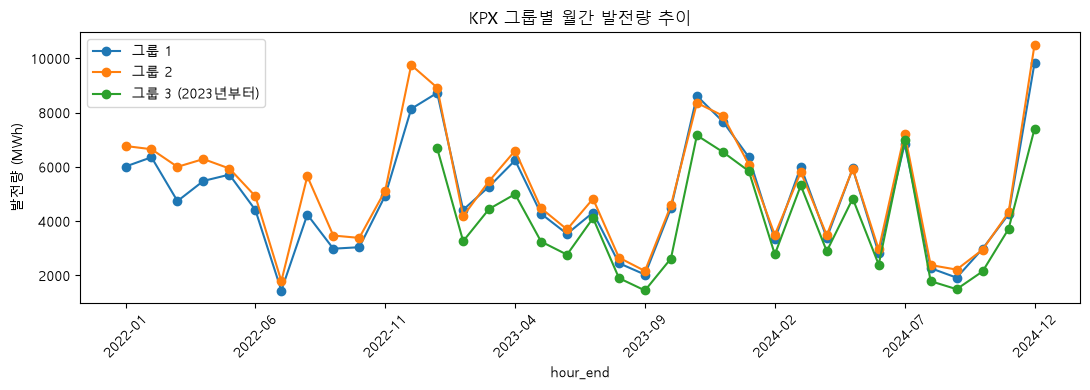

In [44]:
def monthly_sum(hourly_df, power_col):
    # 시간별 표에서 '월별 발전량 합계(MWh)'를 구해주는 함수입니다 (재사용)
    year_month = hourly_df["hour_end"].dt.to_period("M").astype(str)  # 시각을 '2022-01' 같은 월 문자열로 변환
    return hourly_df.groupby(year_month)[power_col].sum() / 1000  # 월별로 합친 뒤 kWh -> MWh로 변환


monthly_g1 = monthly_sum(v_hourly, "kpx_group_1_power")  # 그룹1 월별 발전량
monthly_g2 = monthly_sum(v_hourly, "kpx_group_2_power")  # 그룹2 월별 발전량
monthly_g3 = monthly_sum(u_hourly, "kpx_group_3_power")  # 그룹3 월별 발전량 (2023년부터만 존재)

all_months = monthly_g1.index  # 그룹1 기준(2022-01~2024-12, 36개월) 
monthly_g3 = monthly_g3.reindex(all_months)  # 그룹3에 없는 2022년 달은 채우지 않고 빈 값(NaN)으로 둡니다

plt.figure(figsize=(11, 4))  # 그래프 크기 지정
monthly_g1.plot(marker="o", label="그룹 1")  # 그룹1 선 그리기 (점 표시 포함)
monthly_g2.plot(marker="o", label="그룹 2")  # 그룹2 선 그리기
monthly_g3.plot(marker="o", label="그룹 3 (2023년부터)")  # 그룹3 선 그리기, 2022년 구간은 자동으로 끊겨서 보임
plt.title("KPX 그룹별 월간 발전량 추이")  # 그래프 제목
plt.ylabel("발전량 (MWh)")  # y축 이름
plt.xticks(rotation=45)  # x축 글자를 45도 기울여서 겹치지 않게 함
plt.legend()  # 범례(선 이름표) 표시
plt.tight_layout()  # 여백 자동 정리
plt.show()  # 그래프 출력

## 5. 연도별로 겹쳐서 계절 패턴이 반복되는지 확인하기

1년(1월~12월) -> 주(week) 단위로 잘라, 2022~2023, 2023~2024, 2024~자료 끝을 같은 축에 겹쳐 그립.

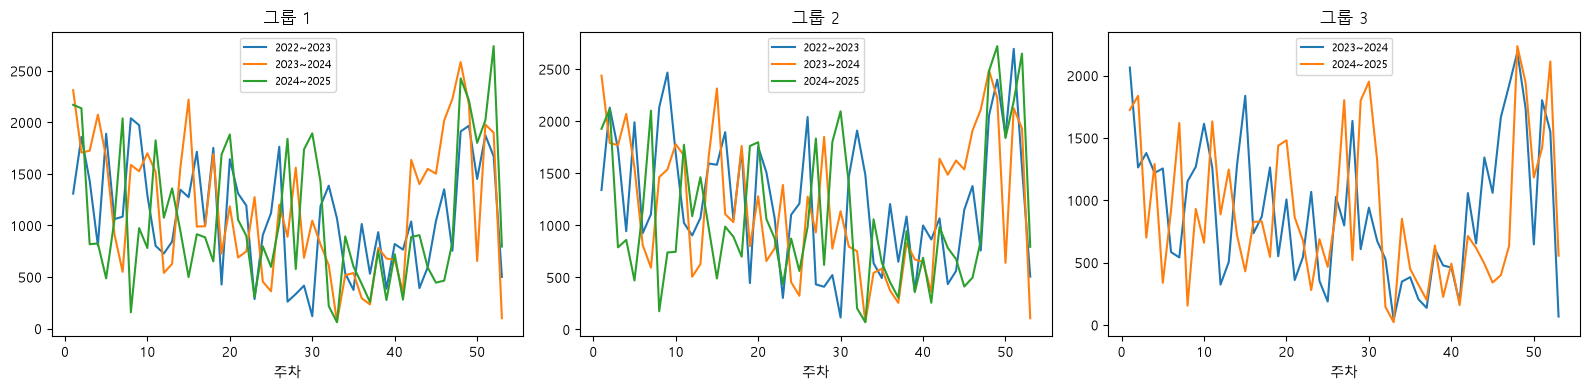

In [51]:
def weekly_by_year(hourly_df, power_col, start_years):
    # 여러 해의 1년 구간을 각각 주차별로 알려줌
    results = {}  # 연도 -> 주별 발전량 시리즈를 담을 사전
    for year in start_years:  # 비교하고 싶은 시작 연도 보기
        start = pd.Timestamp(f"{year}-01-01 01:00:00")  # 그 해의 시작 시각
        end = pd.Timestamp(f"{year + 1}-01-01 00:00:00")  # 그 해의 끝 시각 (다음 해 1월 1일 0시)
        one_year = hourly_df[(hourly_df["hour_end"] >= start) & (hourly_df["hour_end"] <= end)].copy()  # 1년 구간만 자르기
        if one_year[power_col].dropna().empty:  # 그 구간에 데이터가 아예 없으면
            continue  # 건너뜁니다 (예: 그룹3의 2022년)
        day_idx = (one_year["hour_end"] - start).dt.days + 1  # 구간 시작부터 며칠째인지 (1일차, 2일차 ...)
        week_idx = (day_idx - 1) // 7 + 1  # 며칠째를 7로 나눠 몇 주차인지 계산 (1주차, 2주차 ...)
        weekly = one_year.groupby(week_idx)[power_col].sum() / 1000  # 주 단위로 합친 뒤 MWh로 변환
        results[f"{year}~{year + 1}"] = weekly  # 사전에 저장
    return results


# 그룹별로 어떤 시간별 표·컬럼을 쓸지 정리해둡니다 (아래 반복문에서 재사용)
group_info = {
    "그룹 1": (v_hourly, "kpx_group_1_power"),
    "그룹 2": (v_hourly, "kpx_group_2_power"),
    "그룹 3": (u_hourly, "kpx_group_3_power"),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))  # 그룹 3개를 나란히 그릴 그래프 3칸 준비
for ax, (name, (hdf, col)) in zip(axes, group_info.items()):  # 그룹마다 반복
    yearly = weekly_by_year(hdf, col, [2022, 2023, 2024])  # 연도별 주간 발전량 계산
    for label, series in yearly.items():  # 연도별로 선을 하나씩 그림
        series.plot(ax=ax, label=label)  # 같은 칸(ax)에 겹쳐서 그리기
    ax.set_title(name)  # 각 칸 제목
    ax.set_xlabel("주차")  # x축 이름
    ax.legend(fontsize=8)  # 범례 표시
plt.tight_layout()  # 여백 정리
plt.show()  # 출력

## 6. 풍속·풍향과 발전량 비교하기

- 발전량(kWh·MWh)과 풍속(m/s)은 단위가 달라 `twinx()`로 **오른쪽에 축을 하나 더** 만들어 겹쳐 봤다.
- 풍향은 0~360도라 또 단위가 다르므로 별도 그래프로 일단 놔둠
- 그래프 그리는 부분도 함수로 만들어서 그룹 1·2·3 세 번 반복해서 그려본다 (그룹3은 UNISON 표를 써야 해서 헷갈리기 쉬움, 주의)

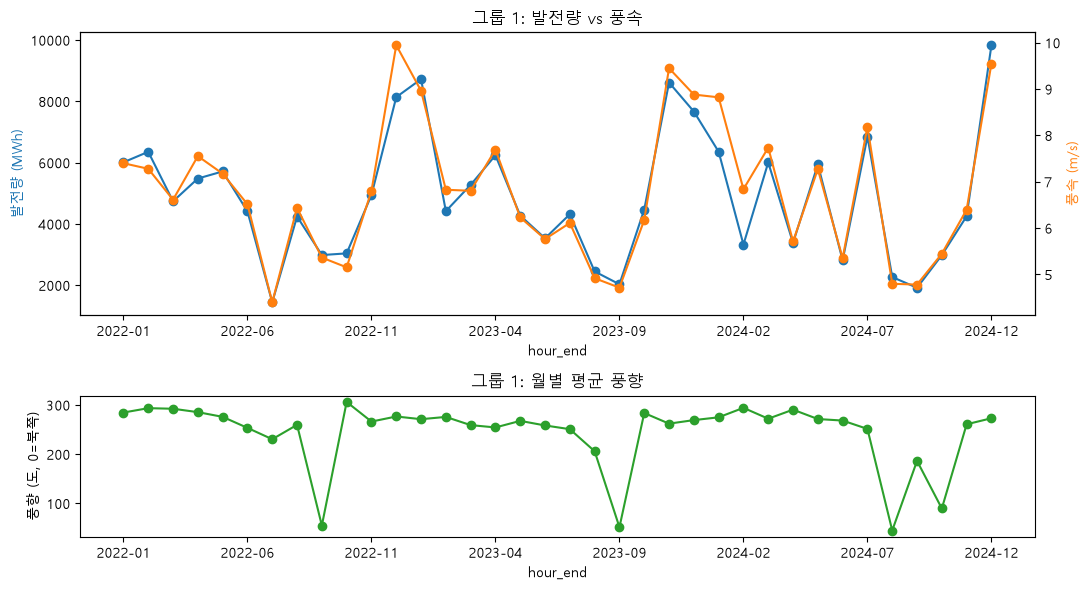

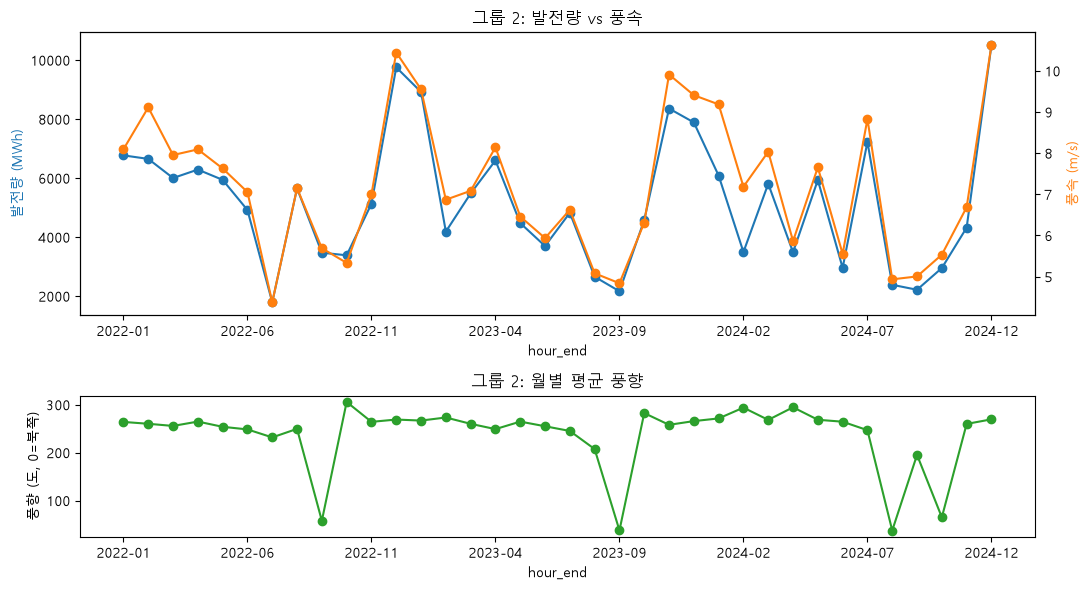

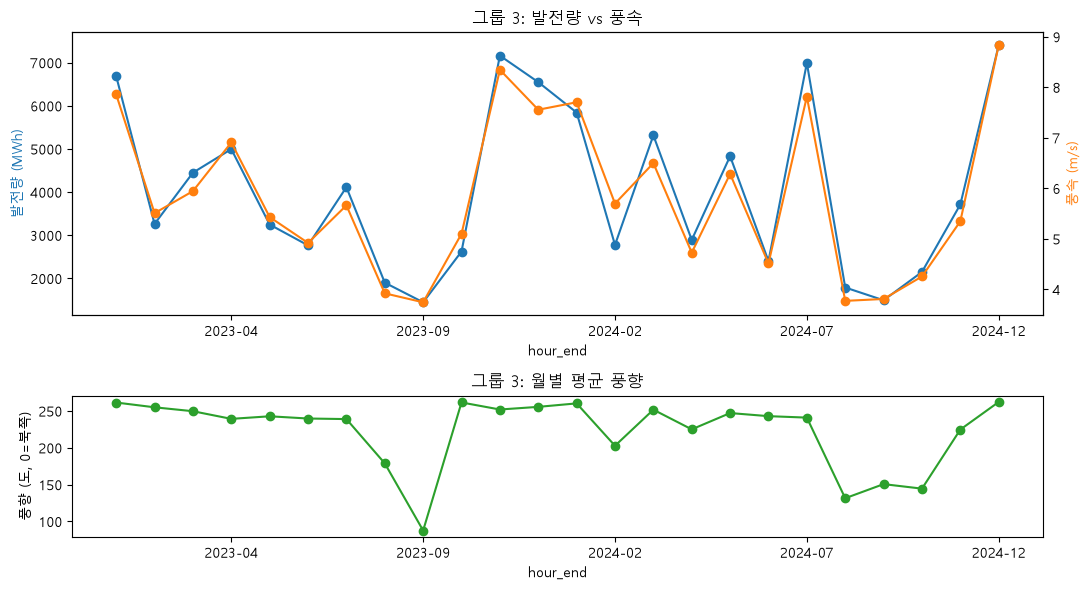

In [ ]:
def monthly_wind(hourly_df, ws_col, wd_col):
    # 시간별 풍속/풍향을 월 단위 평균으로 묶어주는 함수(풍향은 원형 평균 사용)
    year_month = hourly_df["hour_end"].dt.to_period("M").astype(str)  # '2022-01' 같은 월 문자열
    ws_monthly = hourly_df.groupby(year_month)[ws_col].mean()  # 풍속은 그냥 평균
    wd_rad = np.deg2rad(hourly_df[wd_col])  # 풍향을 라디안으로 변환
    sin_m = np.sin(wd_rad).groupby(year_month).mean()  # sin 성분 월평균
    cos_m = np.cos(wd_rad).groupby(year_month).mean()  # cos 성분 월평균
    wd_monthly = (np.degrees(np.arctan2(sin_m, cos_m)) + 360) % 360  # 다시 각도로 복원 (원형 평균)
    return ws_monthly, wd_monthly  # (풍속 시리즈, 풍향 시리즈) 반환


def plot_power_wind(monthly_power, hourly_df, ws_col, wd_col, title):
    # 발전량 vs 풍속(위, twinx로 두 축 겹치기) + 풍향(아래) 그래프를 그려주는 함수 (그룹마다 재사용)
    ws_monthly, wd_monthly = monthly_wind(hourly_df, ws_col, wd_col)  # 이 그룹의 월별 풍속/풍향 계산
    ws_monthly = ws_monthly.reindex(monthly_power.index)  # 발전량과 같은 월 순서로 맞추기 (안 하면 그래프가 밀려서 그려짐!)
    wd_monthly = wd_monthly.reindex(monthly_power.index)  # 풍향도 같은 이유로 월 순서를 맞춰줌

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), height_ratios=[2, 1])  # 위: 발전량+풍속, 아래: 풍향

    monthly_power.plot(ax=ax1, color="tab:blue", marker="o", label="발전량")  # 왼쪽 축에 발전량 그리기
    ax1.set_ylabel("발전량 (MWh)", color="tab:blue")  # 왼쪽 축 이름
    ax1b = ax1.twinx()  # 오른쪽에 새 y축 (단위가 다른 값을 같은 그래프에 겹치기 위해)
    ws_monthly.plot(ax=ax1b, color="tab:orange", marker="o", label="풍속")  # 오른쪽 축에 풍속 그리기
    ax1b.set_ylabel("풍속 (m/s)", color="tab:orange")  # 오른쪽 축 이름
    ax1.set_title(f"{title}: 발전량 vs 풍속")  # 위쪽 그래프 제목

    wd_monthly.plot(ax=ax2, color="tab:green", marker="o")  # 아래쪽에 풍향(도)을 따로 그리기
    ax2.set_ylabel("풍향 (도, 0=북쪽)")  # y축 이름
    ax2.set_title(f"{title}: 월별 평균 풍향")  # 아래쪽 그래프 제목
    # 참고: 풍향은 0도와 360도가 사실 같은 방향이라, 그래프 상에서 위아래로 크게 튀는 구간은 실제로는 방향이 비슷할 수 있습니다

    plt.tight_layout()  # 여백 정리
    plt.show()  # 출력


# 그룹마다 어떤 월별 발전량 · 시간별 표 · 풍속/풍향 컬럼을 쓸지 정리
wind_group_info = {
    "그룹 1": (monthly_g1, v_hourly, "kpx_group_1_ws", "kpx_group_1_wd"),
    "그룹 2": (monthly_g2, v_hourly, "kpx_group_2_ws", "kpx_group_2_wd"),
    "그룹 3": (monthly_g3, u_hourly, "kpx_group_3_ws", "kpx_group_3_wd"),  # 그룹3은 UNISON 표(u_hourly)를 써야 함!
}
for name, (mpower, hdf, wscol, wdcol) in wind_group_info.items():  # 그룹 1, 2, 3을 차례로 반복
    plot_power_wind(mpower, hdf, wscol, wdcol, name)  # 함수 하나로 그룹별 그래프를 각각 그려줌

## 7. 의심: 풍속과 발전량은 정말 관련이 있을까?

**상관계수**(-1~1, 1에 가까울수록 같이 움직임)와 **설비이용률**(설비용량 대비 실제로 얼마나 발전했는지 비율) 확인

In [47]:
group_cap_kwh = {"kpx_group_1": 21600, "kpx_group_2": 21600, "kpx_group_3": 21000}  # 그룹별 시간당 최대 발전량(kWh)

for name, (hdf, pcol, wscol) in {
    "그룹 1": (v_hourly, "kpx_group_1_power", "kpx_group_1_ws"),
    "그룹 2": (v_hourly, "kpx_group_2_power", "kpx_group_2_ws"),
    "그룹 3": (u_hourly, "kpx_group_3_power", "kpx_group_3_ws"),
}.items():  # 그룹마다 반복
    d = hdf[[pcol, wscol]].dropna()  # 발전량·풍속 둘 다 있는 시간만 사용 (결측치 제외)
    corr = d[pcol].corr(d[wscol])  # 피어슨 상관계수 계산 (선형 관계가 얼마나 강한지)
    cap_group = pcol.replace("_power", "")  # "kpx_group_1_power" -> "kpx_group_1"
    capacity_factor = d[pcol].sum() / (group_cap_kwh[cap_group] * len(d)) * 100  # 설비이용률(%) 계산
    print(f"{name}: 발전량-풍속 상관계수 = {corr:.3f},  설비이용률 = {capacity_factor:.1f}%")  # 결과 출력

그룹 1: 발전량-풍속 상관계수 = 0.927,  설비이용률 = 30.9%
그룹 2: 발전량-풍속 상관계수 = 0.939,  설비이용률 = 32.9%
그룹 3: 발전량-풍속 상관계수 = 0.907,  설비이용률 = 26.3%


## 8. 의심2: 풍향에 따라 발전 효율이 달라질까?

물리적으로 풍력 발전량은 풍속의 **세제곱**임.
그래서 `발전량 / 풍속³`을 '풍속 대비 효율'로 보고, 이 값이 풍향(8방위)에 따라 달라지는지 확인한다.
효율이 방향마다 다르면, 터빈들이 서로의 바람을 가리는 **후류(wake) 효과**가 있다고 판단할 것임.

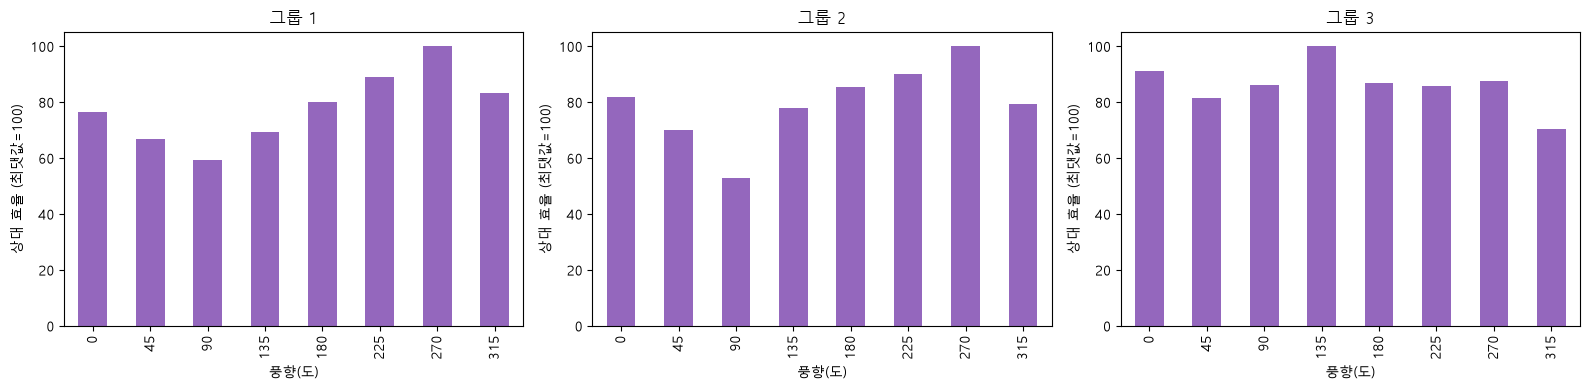

In [48]:
def direction_efficiency(hourly_df, power_col, ws_col, wd_col):
    # 8방위(45도 단위)별 '풍속 대비 발전 효율'을 계산
    d = hourly_df[[power_col, ws_col, wd_col]].dropna()  # 값이 모두 있는 시간만 사용
    d = d[d[ws_col] > 3]  # 풍속이 너무 낮으면(컷인 이하) 애초에 거의 발전을 안 하므로 제외
    coef = d[power_col] / (d[ws_col] ** 3)  # 발전량을 풍속의 세제곱으로 나눠 '효율' 계산
    sector = (d[wd_col] // 45 * 45).astype(int)  # 풍향을 45도 단위 8방위로 묶기 (0,45,90,...,315)
    result = coef.groupby(sector).mean()  # 방위별 평균 효율
    return result / result.max() * 100  # 가장 좋은 방위를 100으로 놓고 상대적으로 비교


fig, axes = plt.subplots(1, 3, figsize=(16, 4))  # 그룹 3개를 나란히 그릴 막대그래프 3칸
for ax, (name, (hdf, pcol, wscol, wdcol)) in zip(axes, {
    "그룹 1": (v_hourly, "kpx_group_1_power", "kpx_group_1_ws", "kpx_group_1_wd"),
    "그룹 2": (v_hourly, "kpx_group_2_power", "kpx_group_2_ws", "kpx_group_2_wd"),
    "그룹 3": (u_hourly, "kpx_group_3_power", "kpx_group_3_ws", "kpx_group_3_wd"),
}.items()):  # 그룹마다 반복
    eff = direction_efficiency(hdf, pcol, wscol, wdcol)  # 방위별 상대 효율 계산
    eff.plot(kind="bar", ax=ax, color="tab:purple")  # 막대그래프로 그리기
    ax.set_title(name)  # 그래프 제목
    ax.set_xlabel("풍향(도)")  # x축 이름
    ax.set_ylabel("상대 효율 (최댓값=100)")  # y축 이름
plt.tight_layout()  # 여백 정리
plt.show()  # 출력

## 9. 의심3: 예보 데이터(LDAPS)만으로도 발전량을 설명할 수 있을까?

실제 예측 상황에서는 SCADA 실측값을 쓸 수 없고, **기상 예보 데이터(LDAPS/GFS)만** 사용한다고 가정해보자.
`ldaps_train.csv`에는 '풍속' 컬럼이 없어서, 지상 10m U/V 바람 성분으로 풍속 크기(`sqrt(u²+v²)`)를 계산한 뒤
SCADA 실측 풍속과 비교해볼 것

In [62]:
ldaps_cols = ["forecast_kst_dtm", "heightAboveGround_10_10u", "heightAboveGround_10_10v"]  # kdt 시간당 동서방향/남북방향 바람 컬럼가져오기
ldaps = pd.read_csv(TRAIN_DIR / "ldaps_train.csv", usecols=ldaps_cols)  # LDAPS 예보 데이터 읽기
ldaps["forecast_kst_dtm"] = pd.to_datetime(ldaps["forecast_kst_dtm"])  # 시간 컬럼을 날짜/시간 타입으로 변환
ldaps["ws10"] = np.sqrt(ldaps["heightAboveGround_10_10u"] ** 2 + ldaps["heightAboveGround_10_10v"] ** 2)  # 피타고라스 정리로 풍속 계산
ldaps_hourly = ldaps.groupby("forecast_kst_dtm")["ws10"].mean()  # 16개 격자를 평균해 지역 대표 풍속(시간별)으로

compare = v_hourly.set_index("hour_end")[["kpx_group_1_power"]].join(ldaps_hourly).dropna()  # 발전량과 예보풍속을 같은 시각끼리 연결
corr_ldaps = compare["kpx_group_1_power"].corr(compare["ws10"])  # 발전량-예보풍속 상관계수
corr_scada = v_hourly["kpx_group_1_power"].corr(v_hourly["kpx_group_1_ws"])  # 발전량-실측풍속 상관계수 (앞에서 계산한 것과 동일)

print(f"발전량 vs LDAPS 예보 풍속(10m) 상관계수 = {corr_ldaps:.3f}")  # 실전에서 쓸 수 있는 입력의 설명력
print(f"발전량 vs SCADA 실측 풍속 상관계수      = {corr_scada:.3f}")  # 참고용 상한선

발전량 vs LDAPS 예보 풍속(10m) 상관계수 = 0.730
발전량 vs SCADA 실측 풍속 상관계수      = 0.927


## 10. 정리

- **월별 발전량**은 겨울(11~1월)에 높고 늦여름(8~9월)에 낮은 패턴이 **3개년 모두 반복**된다.
- **풍속과 발전량은 강한 상관관계**(상관계수 0.9 안팎)가 있지만, 발전량은 풍속의 세제곱보다 풍속 그 자체와 더 강한 상관관계가 있었음. 이는 파워커브 문제일 것이라고 생각된다.
- 풍향도 중요. 그룹 1·2는 방향에 따라 효율이 최대 2배 가까이 차이 나서, 터빈끼리 바람을 가리는 후류 효과가 있는 것으로 보였음
- 풍속이 있어도 발전량이 거의 0인 시간이 1% 안팎 존재: 날씨만으로는 설명 안 되는 날이 있다.
- 실전에서 쓸 수 있는 **LDAPS 예보 풍속은 SCADA 실측 풍속보다 발전량 설명력이 떨어짐** (상관계수가 더 낮음) 
- 그래서 예보 데이터의 한계(격자 해상도, 10m 고도)를 감안하고 1차 모델링 해야함. 그리고 추가로 공간 데이터 찾아봐야겠음.

다음 단계로는 예측모델 피처로 뭐 선정할 지랑~~ 전처리 어떤 단계로 해볼지~~~ 고민해보자.